The objective of this experiment is to develop a News Article Classification system using a Recurrent Neural Network (RNN). The experiment focuses on transforming raw news articles into a machine-readable format through text preprocessing, tokenization, sequence padding, and label encoding. By training the RNN model on categorized news data, the system learns to identify patterns in text and automatically classify unseen news articles into their appropriate categories. This experiment also aims to understand the complete workflow of building, training, and evaluating a deep learning model for natural language processing tasks.


In [12]:
import datasets
# Install the Hugging Face datasets library
!pip install datasets

# Import the required library
from datasets import load_dataset

# Load the AG News dataset
dataset = load_dataset(
    "parquet",
    data_files={
        "train": "/content/train-00000-of-00001.parquet",
        "test": "/content/test-00000-of-00001.parquet",
    },
)

# Split the dataset into training and testing sets
train_data = dataset["train"]
test_data = dataset["test"]

# Display the first training sample
print(train_data[0])

Generating train split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

{'text': "Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\\band of ultra-cynics, are seeing green again.", 'label': 2}


In [13]:
# Import regular expression library
import re

# Function to clean the text
def clean_text(text):
    # Convert text to lowercase
    text = text.lower()

    # Remove punctuation, numbers, and special characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    return text

# Clean all training texts
train_texts = [clean_text(sample["text"]) for sample in train_data]

# Clean all testing texts
test_texts = [clean_text(sample["text"]) for sample in test_data]

# Extract labels
train_labels = [sample["label"] for sample in train_data]
test_labels = [sample["label"] for sample in test_data]

# Display the cleaned text
print(train_texts[0])

wall st bears claw back into the black reuters reuters  shortsellers wall streets dwindlingband of ultracynics are seeing green again


In [14]:
# Import Tokenizer
from tensorflow.keras.preprocessing.text import Tokenizer

# Maximum vocabulary size
vocab_size = 10000

# Create tokenizer object
tokenizer = Tokenizer(
    num_words=vocab_size,
    oov_token="<OOV>"
)

# Build vocabulary using training data
tokenizer.fit_on_texts(train_texts)

# Convert text into integer sequences
train_sequences = tokenizer.texts_to_sequences(train_texts)
test_sequences = tokenizer.texts_to_sequences(test_texts)

# Display first sequence
print(train_sequences[0])

[392, 325, 1526, 1, 100, 55, 2, 813, 24, 24, 1, 392, 1989, 1, 5, 1, 35, 3894, 738, 296]


In [15]:
# Import pad_sequences
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Set maximum sequence length
max_length = 50

# Pad training sequences
X_train = pad_sequences(
    train_sequences,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

# Pad testing sequences
X_test = pad_sequences(
    test_sequences,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

# Display the shape of the training data
print(X_train.shape)

(120000, 50)


In [16]:
# Import one-hot encoding function
from tensorflow.keras.utils import to_categorical

# Number of output classes
num_classes = 4

# Convert labels into one-hot encoded vectors
y_train = to_categorical(train_labels, num_classes)
y_test = to_categorical(test_labels, num_classes)

# Display first encoded label
print(y_train[0])

[0. 0. 1. 0.]


In [17]:
# Import required layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

# Size of embedding vector
embedding_dim = 64

# Create Sequential model
model = Sequential()

# Add Embedding layer
model.add(
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        input_length=max_length
    )
)

# Add SimpleRNN layer
model.add(SimpleRNN(64))

# Add Output layer with Softmax activation
model.add(Dense(num_classes, activation='softmax'))

# Display model summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [18]:
# Compile the model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train the model
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 40s 25ms/step - accuracy: 0.7149 - loss: 0.6833 - val_accuracy: 0.8229 - val_loss: 0.5063
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 39s 26ms/step - accuracy: 0.8852 - loss: 0.3590 - val_accuracy: 0.8717 - val_loss: 0.3929
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 38s 25ms/step - accuracy: 0.9129 - loss: 0.2859 - val_accuracy: 0.8893 - val_loss: 0.3417
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 41s 25ms/step - accuracy: 0.9258 - loss: 0.2426 - val_accuracy: 0.8751 - val_loss: 0.3920
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 40s 26ms/step - accuracy: 0.9367 - loss: 0.2072 - val_accuracy: 0.8653 - val_loss: 0.4608


In [19]:
# Evaluate the model on testing data
loss, accuracy = model.evaluate(X_test, y_test)

# Print the loss and accuracy
print("Test Loss :", loss)
print("Test Accuracy :", accuracy)

238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8764 - loss: 0.4217
Test Loss : 0.4216625988483429
Test Accuracy : 0.8764473795890808


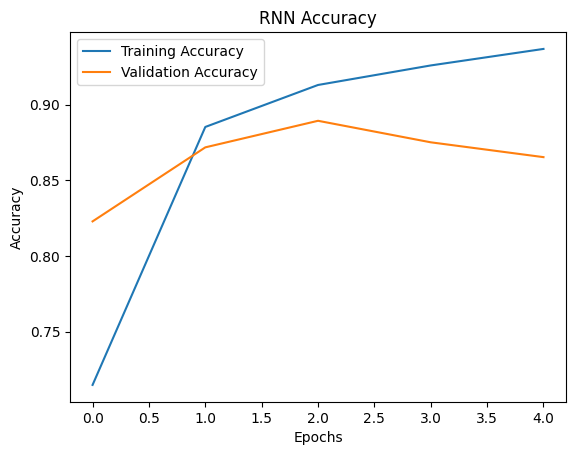

In [20]:
# Import matplotlib
import matplotlib.pyplot as plt

# Plot training accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')

# Plot validation accuracy
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

# Add graph labels
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("RNN Accuracy")

# Display legend
plt.legend()

# Show the graph
plt.show()

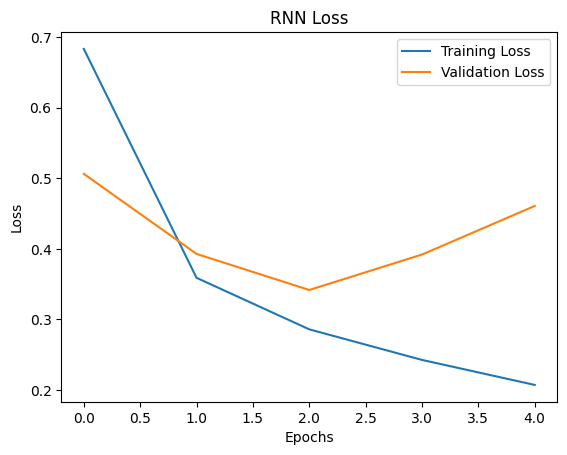

In [21]:
# Plot training loss
plt.plot(history.history['loss'], label='Training Loss')

# Plot validation loss
plt.plot(history.history['val_loss'], label='Validation Loss')

# Add graph labels
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("RNN Loss")

# Display legend
plt.legend()

# Show the graph
plt.show()

* Successfully loaded and prepared the news article dataset for training and testing.
* Cleaned and normalized the text by removing unwanted characters and converting all words to lowercase.
* Converted textual data into numerical sequences using tokenization.
* Applied sequence padding to ensure all input data had a uniform length.
* Encoded the target labels into categorical format for multi-class classification.
* Designed and implemented a Recurrent Neural Network (RNN) using an Embedding layer, a SimpleRNN layer, and a Dense output layer.
* Compiled and trained the model using the Adam optimizer and categorical cross-entropy loss function.
* Evaluated the trained model using test data and measured its classification accuracy.
* Visualized the training and validation performance through accuracy and loss graphs.
* Demonstrated that an RNN can effectively classify news articles into their respective categories based on textual content.
